# Bulgarian TTS — Demo (phoneme FastSpeech 2 + fine-tuned HiFi-GAN)

This notebook presents the trained Bulgarian text-to-speech model end to end:

> **text → phonemes → FastSpeech 2 → HiFi-GAN → audio**

It loads the **latest phoneme checkpoint** and the **fine-tuned HiFi-GAN
generator**, synthesizes speech for a sentence, and plays it inline. Run the
cells from top to bottom.

Phonemization is fully self-contained: known words come from the Bulgarian
runtime lexicon, and any out-of-lexicon word falls back to a built-in
grapheme→phoneme rule set — so **no Montreal Forced Aligner install is
required**.

## 1. Configuration

In [ ]:
# Latest checkpoint is auto-selected from this directory (files named N.pth.tar).
CKPT_DIR = "output/ckpt/Bulgarian"

# Which vocoder turns the mel-spectrogram into audio:
#   "finetuned" = the Bulgarian fine-tuned HiFi-GAN (recommended)
#   "universal" = the bundled multi-speaker HiFi-GAN
VOCODER = "finetuned"

# Fine-tuned Bulgarian HiFi-GAN generator (use g_*, not the do_* discriminator).
FINETUNED_VOCODER = "hifigan_finetune/g_00135000"

# Where the wav/png are written.
RESULT_DIR = "local_inference_results"

# Prosody controls.
DURATION_CONTROL = 1.0   # larger = slower speech
PITCH_CONTROL    = 1.0
ENERGY_CONTROL   = 1.0

## 2. Setup and imports

In [29]:
import os, re, sys
from pathlib import Path

# Resolve the repository root (this notebook lives in notebooks/).
REPO_ROOT = Path.cwd()
if (REPO_ROOT / "synthesize.py").exists():
    pass
elif (REPO_ROOT.parent / "synthesize.py").exists():
    REPO_ROOT = REPO_ROOT.parent
else:
    raise RuntimeError("Run this notebook from inside the repository checkout.")

os.chdir(REPO_ROOT)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import json
import numpy as np
import torch
import yaml

import synthesize as synthesize_module
from synthesize import _load_runtime_lexicon
from utils.model import get_model
import hifigan
from text import text_to_sequence
from bg_text_normalizer import normalize as contextual_normalize
from bulgarian_normalization import normalize_with_punctuation, prosody_words

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

# Load the Bulgarian configuration.
with open("config/Bulgarian/preprocess.yaml", encoding="utf-8") as f:
    preprocess_config = yaml.safe_load(f)
with open("config/Bulgarian/model.yaml", encoding="utf-8") as f:
    model_config = yaml.safe_load(f)
with open("config/Bulgarian/train.yaml", encoding="utf-8") as f:
    train_config = yaml.safe_load(f)

RESULT_DIR = Path(RESULT_DIR)
RESULT_DIR.mkdir(parents=True, exist_ok=True)

TEXT_CLEANERS = preprocess_config["preprocessing"]["text"]["text_cleaners"]


def latest_step(ckpt_dir):
    steps = []
    for p in Path(ckpt_dir).glob("*.pth.tar"):
        m = re.fullmatch(r"(\d+)\.pth\.tar", p.name)
        if m:
            steps.append(int(m.group(1)))
    if not steps:
        raise FileNotFoundError(f"No N.pth.tar checkpoints in {ckpt_dir}")
    return max(steps)


STEP = latest_step(CKPT_DIR)
print("using checkpoint step:", STEP)

device: cpu
using checkpoint step: 60000


## 3. Load FastSpeech 2 (latest phoneme checkpoint)

In [30]:
class _Args:
    restore_step = STEP


# Point the checkpoint loader at the chosen directory.
train_config["path"]["ckpt_path"] = CKPT_DIR

configs = (preprocess_config, model_config, train_config)
model = get_model(_Args(), configs, device, train=False)
print("FastSpeech2 loaded;", sum(p.numel() for p in model.parameters()), "parameters")

FastSpeech2 loaded; 35286849 parameters


## 4. Choose and load the vocoder

Set `VOCODER` in the configuration cell to `"finetuned"` (Bulgarian fine-tuned
generator, recommended) or `"universal"` (the bundled multi-speaker HiFi-GAN).
Re-run this cell after changing it to switch vocoders.

In [31]:
import shutil, zipfile


def _load_generator(ckpt_path):
    """Build a HiFi-GAN generator and load a g_*-style checkpoint."""
    with open("hifigan/config.json") as f:
        cfg = hifigan.AttrDict(json.load(f))
    gen = hifigan.Generator(cfg)
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    assert "generator" in ckpt, (
        f"{ckpt_path} is not a generator checkpoint (needs key 'generator'; "
        "use g_*, not do_*)."
    )
    gen.load_state_dict(ckpt["generator"])
    gen.eval()
    gen.remove_weight_norm()
    return gen.to(device)


def _ensure_universal():
    """Return the universal HiFi-GAN checkpoint, extracting it from the zip if needed."""
    target = Path("hifigan/generator_universal.pth.tar")
    if not target.is_file():
        with zipfile.ZipFile("hifigan/generator_universal.pth.tar.zip") as zf:
            member = next(n for n in zf.namelist()
                          if n.endswith("generator_universal.pth.tar"))
            with zf.open(member) as src, open(target, "wb") as dst:
                shutil.copyfileobj(src, dst)
    return str(target)


if VOCODER == "finetuned":
    vocoder = _load_generator(FINETUNED_VOCODER)
    print("loaded fine-tuned HiFi-GAN:", FINETUNED_VOCODER)
elif VOCODER == "universal":
    vocoder = _load_generator(_ensure_universal())
    print("loaded universal HiFi-GAN: hifigan/generator_universal.pth.tar")
else:
    raise ValueError('VOCODER must be "finetuned" or "universal"')

Removing weight norm...
loaded fine-tuned HiFi-GAN: hifigan_finetune/g_00135000


## 5. Bulgarian phonemizer (runtime lexicon + grapheme fallback)

Each word is looked up in the Bulgarian runtime lexicon. Words that are not in
the lexicon are converted with a built-in grapheme→phoneme rule set, so the
demo works for arbitrary Bulgarian text without Montreal Forced Aligner. Every
emitted symbol is part of the model's frozen phone inventory
(`text/bulgarian_mfa_phones.py`).

In [32]:
# Load the runtime lexicon once (word -> list of MFA phones).
RUNTIME_LEXICON = _load_runtime_lexicon("lexicon/bulgarian_mfa_runtime.dict")
print("runtime lexicon entries:", len(RUNTIME_LEXICON))

# Base (context-free) Cyrillic letter -> MFA phone(s). Good enough for a demo;
# the lexicon already covers most words with full MFA-quality pronunciations.
_BG_G2P = {
    "а": ["a"],  "б": ["b"],  "в": ["v"],  "г": ["ɡ"],  "д": ["d̪"],
    "е": ["ɛ"],  "ж": ["ʒ"],  "з": ["z̪"], "и": ["i"],  "й": ["j"],
    "к": ["k"],  "л": ["ɫ"],  "м": ["m"],  "н": ["n̪"], "о": ["o"],
    "п": ["p"],  "р": ["r"],  "с": ["s̪"], "т": ["t̪"], "у": ["u"],
    "ф": ["f"],  "х": ["x"],  "ц": ["t̪s̪"], "ч": ["tʃ"], "ш": ["ʃ"],
    "щ": ["ʃ", "t̪"], "ъ": ["ɤ"], "ь": [], "ю": ["j", "u"], "я": ["j", "a"],
}


def grapheme_g2p(word):
    """Convert an out-of-lexicon Bulgarian word to MFA phones (rule-based)."""
    phones, i, w = [], 0, word.lower()
    while i < len(w):
        if w[i] == "д" and i + 1 < len(w) and w[i + 1] == "ж":  # дж -> dʒ
            phones.append("dʒ")
            i += 2
            continue
        phones.extend(_BG_G2P.get(w[i], []))
        i += 1
    return phones


def text_to_phones(text):
    """Build a braced MFA-phone string and the list of words taken from fallback."""
    pairs = prosody_words(text)
    phone_list, oov = [], []
    for index, (word, punctuation) in enumerate(pairs):
        if word in RUNTIME_LEXICON:
            phones = RUNTIME_LEXICON[word]
        else:
            phones = grapheme_g2p(word)
            oov.append(word)
        phone_list.extend(phones)
        if punctuation:
            phone_list.append(punctuation)
        elif index < len(pairs) - 1:
            phone_list.append("wb")
    return "{" + " ".join(phone_list) + "}", oov

runtime lexicon entries: 48653


## 6. Text → phonemes

In [54]:
# Text to synthesize.
raw_text = "Господарската трапеза беше сложена, както по обикновение, под лозата, между бистрия и студен чучур на барата, който като лястовичка пееше, деня и нощя, и между високите бухлати чемшири, що се тъмнееха край зида, зиме и лете все зелени."

normalized_text = normalize_with_punctuation(contextual_normalize(raw_text))

phones, oov = text_to_phones(normalized_text)
phone_ids = np.array(text_to_sequence(phones, TEXT_CLEANERS), dtype=np.int64)

print("Raw text:       ", raw_text)
print("Normalized text:", normalized_text)
print("Phoneme sequence:", phones)
if oov:
    print("Grapheme fallback used for:", oov)
print("phoneme tokens:", len(phone_ids))

Raw text:        Господарската трапеза беше сложена, както по обикновение, под лозата, между бистрия и студен чучур на барата, който като лястовичка пееше, деня и нощя, и между високите бухлати чемшири, що се тъмнееха край зида, зиме и лете все зелени.
Normalized text: господарската трапеза беше сложена, както по обикновение, под лозата, между бистрия и студен чучур на барата, който като лястовичка пееше, деня и нощя, и между високите бухлати чемшири, що се тъмнееха край зида, зиме и лете все зелени.
Phoneme sequence: {ɡ o s̪ p o d̪ a r s̪ k a t̪ a wb t̪ r a p ɛ z̪ a wb b ɛ ʃ ɛ wb s̪ ɫ ɔ ʒ ɛ n̪ ɤ p_comma k a k t̪ o wb p o wb o b i k n̪ o v ɛ n̪ i ɛ p_comma p ɔ t̪ wb ɫ ɔ z̪ ɤ t̪ ɤ p_comma m ɛ ʒ d̪ u wb b i s̪ t̪ r i j a wb i wb s̪ t̪ u d̪ ɛ n̪ wb tʃ u tʃ u r wb n̪ ɤ wb b a r a t̪ a p_comma k ɔ j t̪ o wb k ɤ t̪ ɔ wb ɫ j a s̪ t̪ o v i tʃ k a wb p ɛ ɛ ʃ ɛ p_comma d̪ ɛ ɲ ɤ wb i wb n̪ o ʃ tʲ a p_comma i wb m ɛ ʒ d̪ u wb vʲ i s̪ ɔ c i t̪ ɛ wb b u x ɫ a t̪ i wb tʃ ɛ m ʃ i rʲ i p_comma ʃ t̪ ɔ w

## 7. FastSpeech 2 → mel → HiFi-GAN → audio

wav: local_inference_results\demo.wav
png: local_inference_results\demo.png


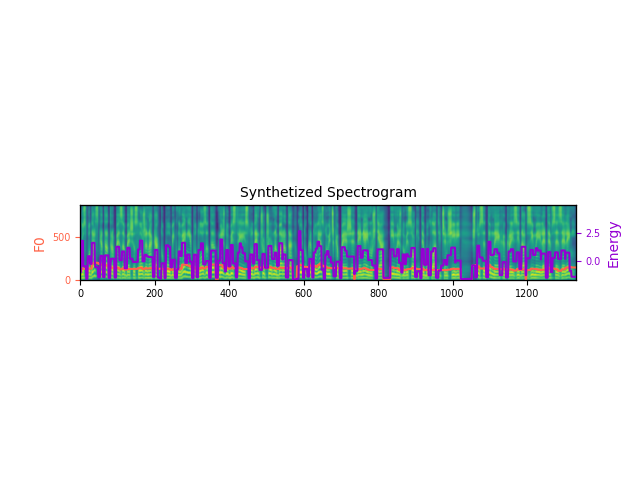

In [55]:
from IPython.display import Audio, Image, display

output_id = "demo"
batchs = [(
    [output_id],            # ids
    [raw_text],             # raw_texts
    np.array([0]),          # speakers
    np.array([phone_ids]),  # phone-id sequences
    np.array([len(phone_ids)]),
    len(phone_ids),
)]
control_values = (PITCH_CONTROL, ENERGY_CONTROL, DURATION_CONTROL)

train_config["path"]["result_path"] = str(RESULT_DIR)
configs = (preprocess_config, model_config, train_config)

# FastSpeech2 forward pass + HiFi-GAN vocoder; writes <output_id>.wav and .png.
synthesize_module.synthesize(model, STEP, configs, vocoder, batchs, control_values)

wav_path = RESULT_DIR / f"{output_id}.wav"
png_path = RESULT_DIR / f"{output_id}.png"
print("wav:", wav_path)
print("png:", png_path)

display(Image(filename=str(png_path)))
display(Audio(filename=str(wav_path)))

## Notes

- Switch between the fine-tuned and universal vocoder by setting `VOCODER` in the
  configuration cell and re-running cell 4.
- Change `TEXT` and re-run cells 6 and 7 to synthesize another sentence.
- `DURATION_CONTROL` adjusts speaking rate (larger = slower); `PITCH_CONTROL`
  and `ENERGY_CONTROL` scale pitch and loudness.
- In-lexicon words use full MFA-quality pronunciations; out-of-lexicon words use
  the built-in grapheme fallback (intelligible, slightly less precise on
  stress/palatalization).